In [1]:
from pathlib import Path
import pandas as pd
import woodsort.nwb as nwb 
import pynapple as nap
import spikeinterface.full as si
from probeinterface import read_probeinterface
import warnings
import importlib

importlib.reload(nwb)


<module 'woodsort.nwb' from '/home/avadher/woodsort/woodsort/woodsort/nwb/__init__.py'>

In [5]:
### SPECIFY PATHS ### 

data_path = Path('/home/avadher/Data/Trisha/')
session_name = 'H8003-260112'
meta_name = 'H8000_metadata.xlsx'
analyzer_name = session_name + '_analyzer_mountainsort5'
session_path = list(data_path.rglob(session_name))[0] # find session_name folder inside data_path 
nwb_path = session_path
processed_path = session_path / 'Processed'
analyzer_path = processed_path / analyzer_name
lfp_path = processed_path / 'continuous.lfp'
probegroup_path = processed_path / 'probegroup.json'

# Ignore annoying warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


In [11]:
### LOAD DATA ###

# load metadata
metadata = nwb.io.read_metadata_excel(data_path / meta_name, session_name, print_output=True)
probe = read_probeinterface(probegroup_path)
start_time = nwb.io.get_start_time(session_path)

# load data
epochs = pd.read_csv(processed_path / 'EpochTimestamps.csv', header=0)
events = pd.read_csv(processed_path / 'EventTimestamps.csv', header=0)[6:] # First 2 x n_used_squares events are an artifact (e.g. 6 if using 3 squares)
tracking = pd.read_csv(processed_path / 'TrackingProcessed.csv',index_col=0, header=0)
pos = nap.TsdFrame(tracking[["x", "y"]])
hd = nap.Tsd(tracking['hd'])

# load SpikeInterface analyzer
analyzer = si.load_sorting_analyzer(analyzer_path)


{'epoch': {'1': 'wake', '2': 'sleep', '3': 'wake_cue_rot'},
 'file': {'experiment_description': 'Reorientation in the head-direction system',
          'experimenter': 'Narayanan, Trisha',
          'institution': 'University of Edinburgh',
          'lab': 'Wood/Dudchenko lab',
          'name': 'H8003-260112',
          'protocol': 'day1',
          'session_description': 'Cue rotations (45, 90 deg)'},
 'probe': [{'id': 1, 'location': 'left postsubiculum'}],
 'subject': {'dob': 111111, 'genotype': None, 'line': 'Fmr1', 'sex': 'M', 'stock_id': 9999999}}

Start time from sync_messages.txt: 2026-01-12 19:49:32.253000+00:00


In [13]:
### NWB ### 

#Create NWB file
nwbfile = nwb.convert.create_nwb_file(metadata, start_time)

# Add units from spikeinterface
nwbfile = nwb.convert.add_spikeinterface_openephys(nwbfile, analyzer, probe=probe, merging_mode='soft')

# Add tracking
nwbfile = nwb.convert.add_tracking(nwbfile, pos, hd)

# Add epochs
nwbfile = nwb.convert.add_epochs(nwbfile, epochs, metadata)

# Add events 
nwbfile = nwb.convert.add_event_intervals(nwbfile, events)

#Add LFP
nwbfile = nwb.convert.add_lfp(nwbfile, lfp_path)

# Save NWB file
nwb.convert.save_nwb_file(nwbfile, nwb_path, session_name)

# Load to check
rec = nwb.convert.load_nwb_file(nwb_path, session_name)


Creating NWB file and adding metadata...

Adding SpikeInterface units and metrics to the NWB file...

Applying curation from file /home/avadher/Data/Trisha/H8003/H8003-260112/Processed/H8003-260112_analyzer_mountainsort5/spikeinterface_gui/curation_data.json


/home/avadher/.conda/envs/woodsort/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/avadher/.conda/envs/woodsort/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/avadher/.conda/envs/woodsort/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/avadher/.conda/envs/woodsort/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


noise_level (workers: 12 processes):   0%|          | 0/20 [00:00<?, ?it/s]

calculate_pc_metrics:   0%|          | 0/3 [00:00<?, ?it/s]

Adding tracking to NWB file...
Adding epochs to NWB file...
Adding events to NWB file...
Adding LFP to the NWB file...
Saving NWB file...
Done!
H8003-260112
┍━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys           │ Type        │
┝━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units          │ TsGroup     │
│ events         │ IntervalSet │
│ epochs         │ IntervalSet │
│ LFP            │ TsdFrame    │
│ position       │ TsdFrame    │
│ head-direction │ Tsd         │
┕━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙


/home/avadher/.conda/envs/woodsort/lib/python3.10/site-packages/hdmf/utils.py:592: DeprecationWarning: The 'manufacturer' field is deprecated. Instead, use DeviceModel.manufacturer and link to that DeviceModel from this Device.
  return func(args[0], **pargs)


{'Probe': Probe pynwb.device.Device at 0x127630456769456
Fields:
  description: ASSY-156-H7
  manufacturer: cambridgeneurotech
}
   location  \
id            
0   unknown   
1   unknown   
2   unknown   
3   unknown   
4   unknown   
5   unknown   
6   unknown   
7   unknown   
8   unknown   
9   unknown   
10  unknown   
11  unknown   
12  unknown   
13  unknown   
14  unknown   
15  unknown   
16  unknown   
17  unknown   
18  unknown   
19  unknown   
20  unknown   
21  unknown   
22  unknown   
23  unknown   
24  unknown   
25  unknown   
26  unknown   
27  unknown   
28  unknown   
29  unknown   
30  unknown   
31  unknown   
32  unknown   
33  unknown   
34  unknown   
35  unknown   
36  unknown   
37  unknown   
38  unknown   
39  unknown   
40  unknown   
41  unknown   
42  unknown   
43  unknown   
44  unknown   
45  unknown   
46  unknown   
47  unknown   
48  unknown   
49  unknown   
50  unknown   
51  unknown   
52  unknown   
53  unknown   
54  unknown   
55  unknown   
5

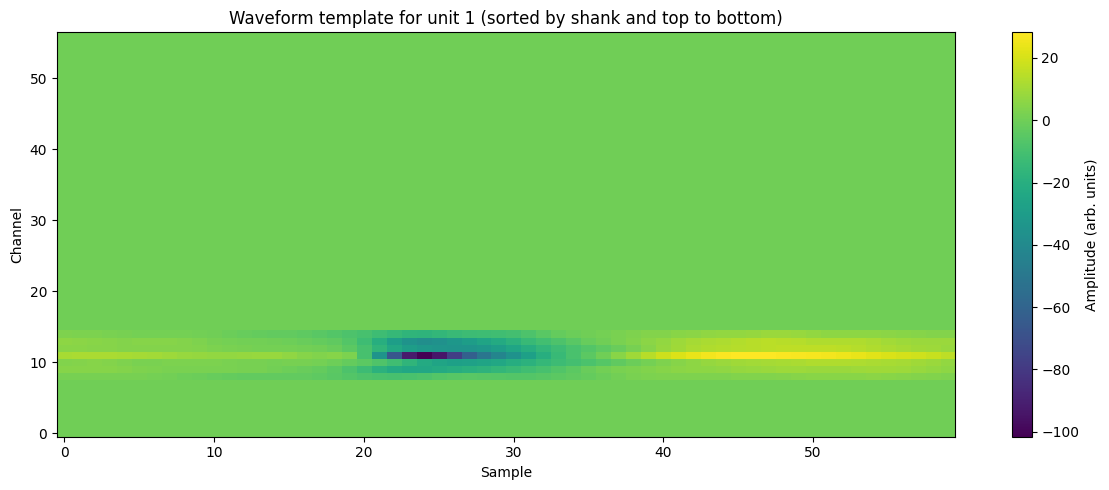

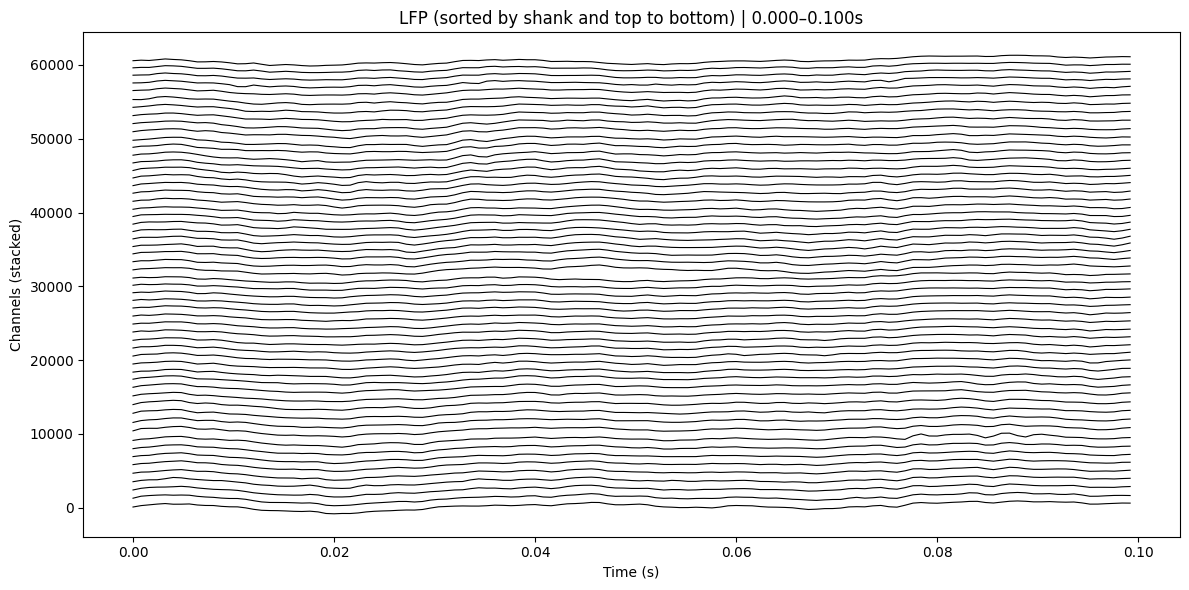

In [14]:
nwb.test.test_nwbfile(nwbfile, t_start=0.0, t_end=0.1, cell_number=1, show_tables=True)